In [5]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data

# Market Strategies Comparison Notebook

This notebook explores and compares several investment strategies using historical market data:

1. **Leveraged SPY ETF vs Regular SPY**  
    Analyze the performance differences between a leveraged SPY ETF and the standard SPY index. Visualizations and metrics will highlight risk and return profiles.

2. **ML/LLM-Generated Strategy vs Index**  
    Implement a typical strategy generated by machine learning or large language models. Compare its results against major indices (e.g., SPY, QQQ) to evaluate predictive power and robustness.

3. **Momentum Strategy**  
    Construct and backtest a momentum-based strategy designed to outperform the market. Assess its effectiveness using return, volatility, and drawdown statistics.

Throughout the notebook, we will use Python and pandas for data manipulation, and visualize results to facilitate clear, actionable insights.

In [4]:
tickers = get_tickers(mod="1.1")

tickers

['AMZN', 'NVDA']

In [6]:
# DataFrame to store everything
df_prices = pd.DataFrame()

for ticker in tickers:
    df = get_market_data(
        ticker=ticker, 
        start_date='2010-01-01', 
        end_date='2025-01-01', 
        returns=False
    )
    
    prices = df['close'].rename(ticker)
    
    df_prices = pd.concat([df_prices, prices], axis=1)
    
    print(f'Data Ready for {ticker}')

Data Ready for AMZN
Data Ready for NVDA


In [59]:
# Get historical price data for VOO and leveraged SPY ETF (e.g., SSO for 2x leveraged SPY)
voo_df = get_market_data(
    ticker='VOO',
    start_date='2011-01-01',
    end_date='2025-01-01',
    returns=False
)

sso_df = get_market_data(
    ticker='SSO',
    start_date='2011-01-01',
    end_date='2025-01-01',
    returns=False
)

# Calculate daily returns
voo_returns = voo_df['close'].pct_change().dropna().to_frame(name='VOO_Return')
sso_returns = sso_df['close'].pct_change().dropna().to_frame(name='SSO_Return')

<Axes: xlabel='Date'>

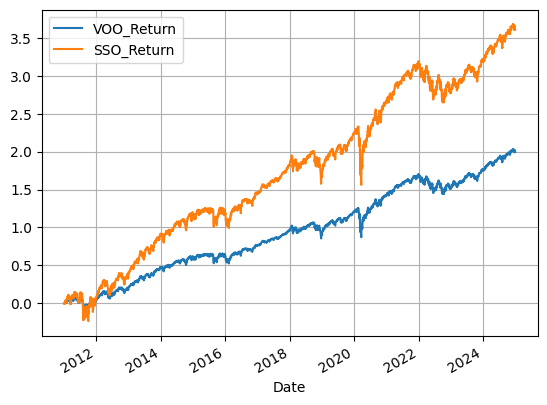

In [60]:
ax=voo_returns.cumsum().plot()
sso_returns.cumsum().plot(ax=ax, grid=True)

In [62]:
# We can use StatsModels efficiently to get the betas for the whole history
import statsmodels.api as sm
import numpy as np
from factors_toolkit import wexp

betas_list = []
tickers = ['SSO']
# Loop to Obtain Betas and Alpha + Residuals
for ticker in tickers:
    # Define series
    y_series = sso_returns.dropna()
    
    # Set the Window
    window = len(y_series)
    weights = window * wexp(window, window/2)
    
    # Define weights
    model = sm.WLS(y_series, voo_returns.loc[y_series.index], weights=weights)
    results = model.fit()
    
    beta = results.params.iloc[0]
    
    betas_list.append(beta)

# Create Beta Series
betas_series = pd.Series(betas_list, index=tickers)
betas_series.name = 'history_beta'

betas_series

SSO    1.991094
Name: history_beta, dtype: float64

In [68]:
voo_returns.dropna()

,VOO_Return
Date,
2011-01-04,-0.000860
2011-01-05,0.005339
2011-01-06,-0.001713
2011-01-07,-0.002059
2011-01-10,-0.000860
...,...
2024-12-24,0.010289
2024-12-26,-0.000018
2024-12-27,-0.010365


In [69]:
sso_returns.dropna()

,SSO_Return
Date,
2011-01-04,-0.001429
2011-01-05,0.010430
2011-01-06,-0.003643
2011-01-07,-0.003860
2011-01-10,-0.002651
...,...
2024-12-24,0.021156
2024-12-26,0.000205
2024-12-27,-0.021329


In [74]:
# Let us get the betas of each stock
from regression_toolkit import rolling_wls_regression, add_constant

voo_returns_const = add_constant(voo_returns)
sso_returns_const = add_constant(sso_returns)


coefficients = rolling_wls_regression(
    sso_returns_const.dropna(),
    voo_returns_const.dropna()
)

coefficients

{'alphas':             constant  SSO_Return
 Date                            
 2012-01-03       1.0   -0.000050
 2012-01-04       1.0   -0.000057
 2012-01-05       1.0   -0.000058
 2012-01-06       1.0   -0.000058
 2012-01-09       1.0   -0.000062
 ...              ...         ...
 2024-12-24       1.0   -0.000261
 2024-12-26       1.0   -0.000257
 2024-12-27       1.0   -0.000261
 2024-12-30       1.0   -0.000267
 2024-12-31       1.0   -0.000264
 
 [3270 rows x 2 columns],
 'betas':                 constant  SSO_Return
 Date                                
 2012-01-03  6.294792e-17    2.008337
 2012-01-04  3.460718e-17    2.008303
 2012-01-05  1.081970e-16    2.008293
 2012-01-06 -4.361447e-17    2.008289
 2012-01-09 -9.593777e-17    2.008276
 ...                  ...         ...
 2024-12-24  3.587326e-15    1.990271
 2024-12-26  4.014997e-16    1.990239
 2024-12-27  1.342144e-15    1.990792
 2024-12-30  2.054451e-15    1.991629
 2024-12-31  6.890217e-16    1.991403
 
 [3270 rows x 2

/var/folders/rn/f9h2pqn14d3ffhfg440r3vkm0000gn/T/ipykernel_69749/293963412.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
/var/folders/rn/f9h2pqn14d3ffhfg440r3vkm0000gn/T/ipykernel_69749/293963412.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
/var/folders/rn/f9h2pqn14d3ffhfg440r3vkm0000gn/T/ipykernel_69749/293963412.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys wil

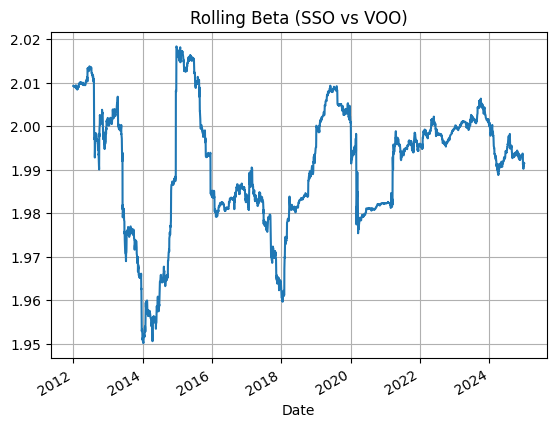

In [70]:
import statsmodels.api as sm

# Align indexes and drop missing values
returns_df = pd.concat([sso_returns, voo_returns], axis=1).dropna()

window = 252  # 1-year rolling window (trading days)
rolling_beta = returns_df['SSO_Return'].rolling(window).apply(
    lambda x: sm.OLS(x, sm.add_constant(returns_df['VOO_Return'][x.index])).fit().params[1]
)

rolling_beta.plot(title='Rolling Beta (SSO vs VOO)', grid=True);

In [76]:
betas_df = coefficients['betas']
betas_df

,constant,SSO_Return
Date,,
2012-01-03,6.294792e-17,2.008337
2012-01-04,3.460718e-17,2.008303
2012-01-05,1.081970e-16,2.008293
2012-01-06,-4.361447e-17,2.008289
2012-01-09,-9.593777e-17,2.008276
...,...,...
2024-12-24,3.587326e-15,1.990271
2024-12-26,4.014997e-16,1.990239
2024-12-27,1.342144e-15,1.990792


In [83]:
from factors_toolkit import compute_factor_contributions, compute_residual_returns

# Cut DataFrames
# Create Beta's DataFrame
betas_df = coefficients['betas']
stock_beta = betas_df['SSO_Return']
r_i = sso_returns['SSO_Return'].loc[stock_beta.index]
r_m = voo_returns['VOO_Return'].loc[stock_beta.index]

# Calculate factor returns
r_f = compute_factor_contributions(r_m, stock_beta)

# Calculate residual returns
residual_returns = compute_residual_returns(r_i, r_m, stock_beta)
residual_returns.name = 'residual_returns'

residual_returns


Date
2012-01-03    0.001112
2012-01-04   -0.000936
2012-01-05   -0.000276
2012-01-06   -0.000033
2012-01-09   -0.000593
                ...   
2024-12-24    0.000679
2024-12-26    0.000241
2024-12-27   -0.000694
2024-12-30   -0.000880
2024-12-31    0.000195
Name: residual_returns, Length: 3270, dtype: float64

In [82]:
r_m

,VOO_Return
Date,
2012-01-03,0.014795
2012-01-04,0.001716
2012-01-05,0.003253
2012-01-06,-0.002048
2012-01-09,0.001539
...,...
2024-12-24,0.010289
2024-12-26,-0.000018
2024-12-27,-0.010365


In [84]:
r_f

Date
2012-01-03    0.029714
2012-01-04    0.003445
2012-01-05    0.006533
2012-01-06   -0.004113
2012-01-09    0.003091
                ...   
2024-12-24    0.020478
2024-12-26   -0.000036
2024-12-27   -0.020635
2024-12-30   -0.022171
2024-12-31   -0.008024
Length: 3270, dtype: float64

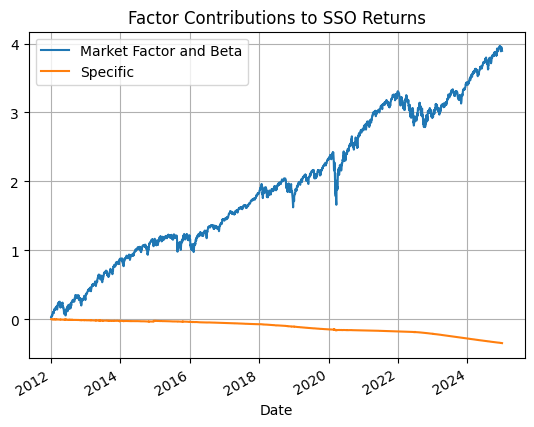

In [85]:
ax=r_f.cumsum().plot(title='Factor Contributions to SSO Returns', grid=True);
residual_returns.cumsum().plot(ax=ax, grid=True);
ax.legend(['Market Factor and Beta', 'Specific']);